In [3]:
from yolov3 import *

model = make_yolov3_model()
weight_reader = WeightReader("Data/yolov3.weights")
weight_reader.load_weights(model)
model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, None, None, 3)]      0         []                            
                                                                                                  
 conv_0 (Conv2D)             (None, None, None, 32)       864       ['input_3[0][0]']             
                                                                                                  
 bnorm_0 (BatchNormalizatio  (None, None, None, 32)       128       ['conv_0[0][0]']              
 n)                                                                                               
                                                                                                  
 leaky_0 (LeakyReLU)         (None, None, None, 32)       0         ['bnorm_0[0][0]']       

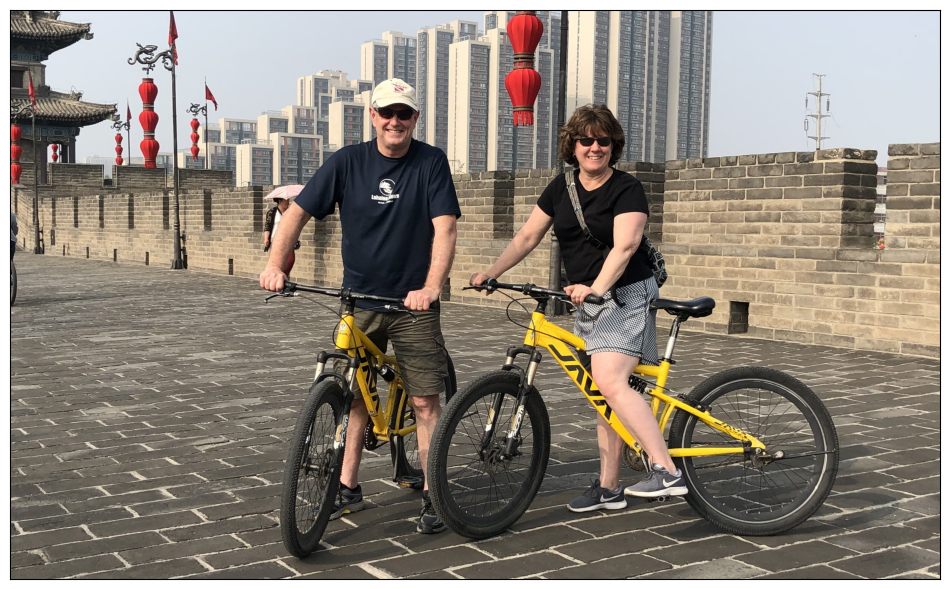

In [6]:
import matplotlib.pyplot as plt
from PIL import Image


def show_image(path: str):
    image = Image.open(path)
    fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"xticks": [], "yticks": []})
    ax.imshow(image)


show_image("Data/xian.jpg")

In [8]:
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array, load_img

X = load_img("Data/xian.jpg", target_size=(YOLO3.width, YOLO3.height))
X = img_to_array(X) / 255
X = np.expand_dims(X, axis=0)
y = model.predict(X)

1/1 [==============================] - 0s 140ms/step


In [9]:
image = plt.imread("Data/xian.jpg")
width, height = image.shape[1], image.shape[0]

boxes = decode_predictions(y, width, height)

for box in boxes:
    print(
        f"({box.xmin}, {box.ymin}), ({box.xmax}, {box.ymax}), {box.label}, {box.score}"
    )

(692, 232), (1303, 1490), person, 0.9970048069953918
(1314, 327), (1920, 1496), person, 0.9957387447357178
(716, 786), (1277, 1634), bicycle, 0.9924144744873047
(1210, 845), (2397, 1600), bicycle, 0.9957170486450195


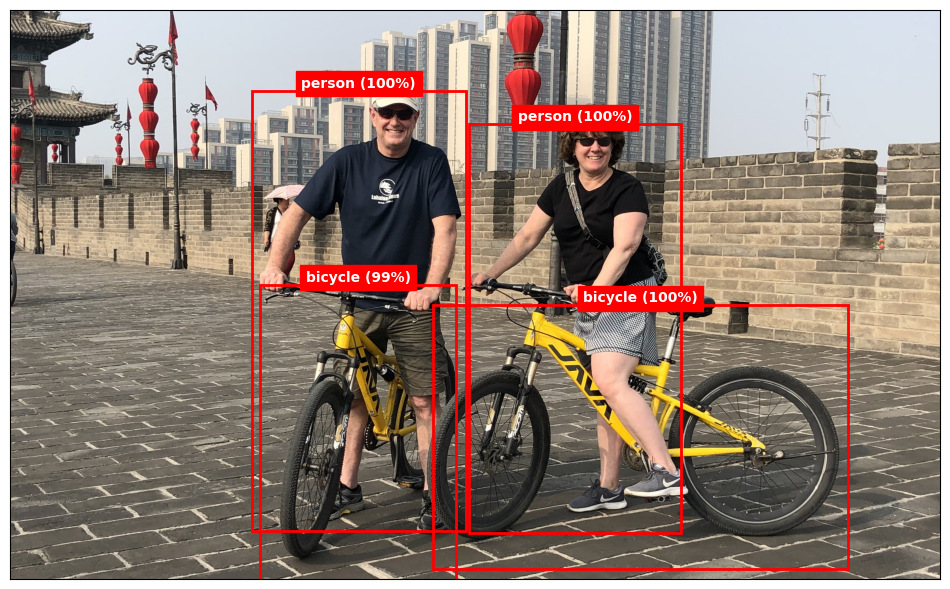

In [10]:
annotate_image("Data/xian.jpg", boxes)

1/1 [==============================] - 0s 141ms/step
(46, 27), (2763, 2707), person, 0.9308187961578369
(510, 1232), (1716, 2237), laptop, 0.9789466857910156


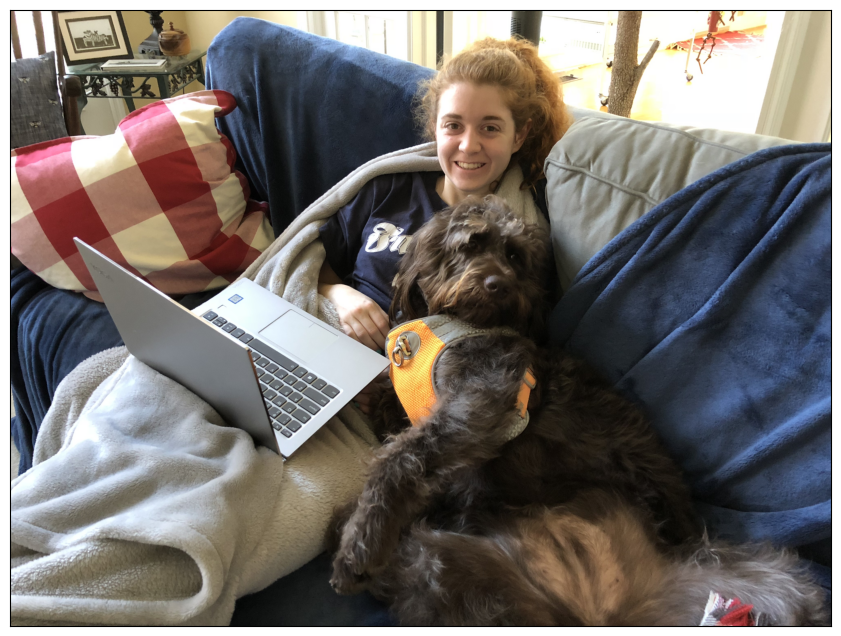

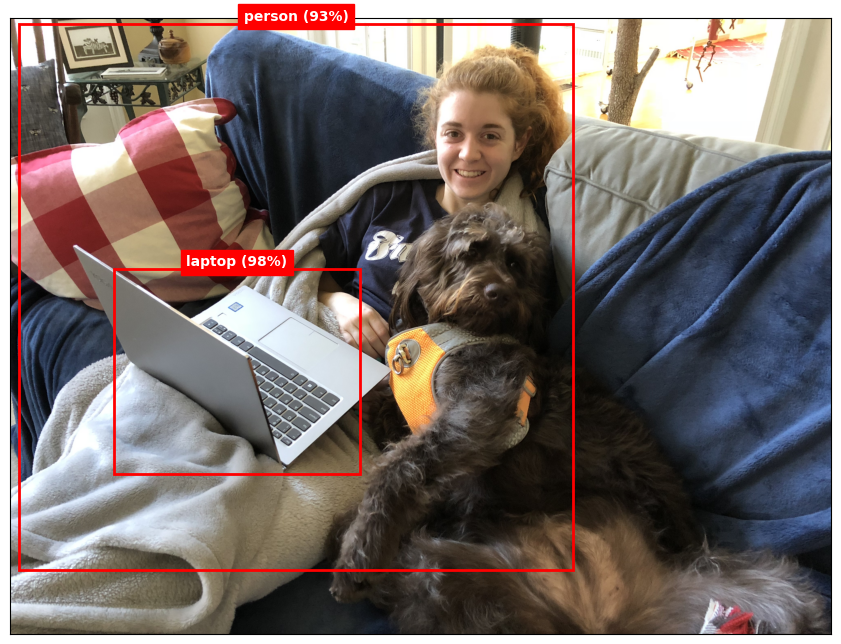

In [11]:
show_image("Data/abby-lady.jpg")

image = plt.imread("Data/abby-lady.jpg")
width, height = image.shape[1], image.shape[0]


X = load_img("Data/abby-lady.jpg", target_size=(YOLO3.width, YOLO3.height))
X = img_to_array(X) / 255
X = np.expand_dims(X, axis=0)
y = model.predict(X)
boxes = decode_predictions(y, width, height)

for box in boxes:
    print(
        f"({box.xmin}, {box.ymin}), ({box.xmax}, {box.ymax}), {box.label}, {box.score}"
    )

annotate_image("Data/abby-lady.jpg", boxes)

(46, 27), (2763, 2707), person, 0.9308187961578369
(14, 271), (3418, 2866), sofa, 0.6722344756126404
(510, 1232), (1716, 2237), laptop, 0.9789466857910156
(1485, 975), (3804, 3185), dog, 0.5572287440299988


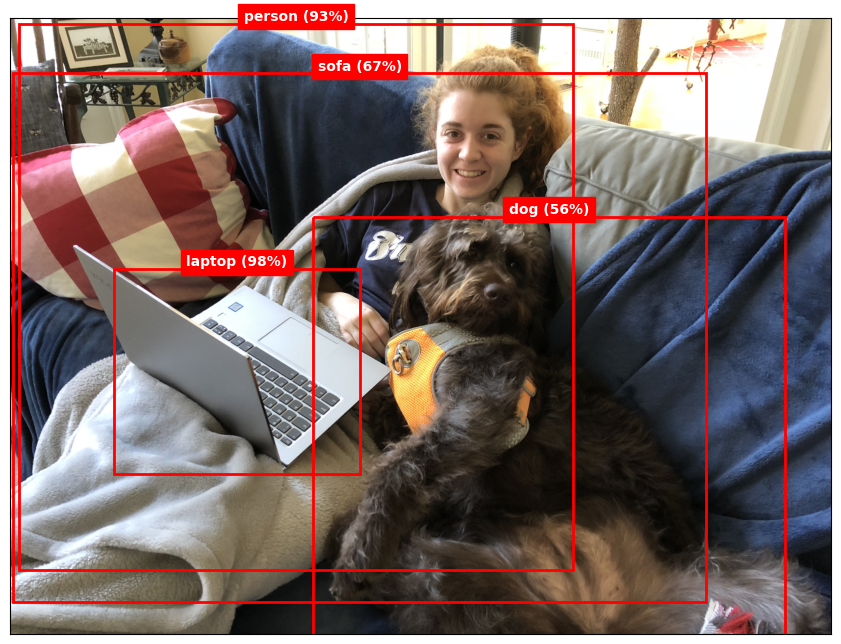

In [12]:
boxes = decode_predictions(y, width, height, min_score=0.55)

for box in boxes:
    print(
        f"({box.xmin}, {box.ymin}), ({box.xmax}, {box.ymax}), {box.label}, {box.score}"
    )

annotate_image("Data/abby-lady.jpg", boxes)